In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
sns.set_style('whitegrid')


In [3]:
df = pd.read_csv('../Data/cleaned_data.csv')

X_text = df['cleaned_text'].fillna('')
y = df['fraudulent']

metadata_cols = ['telecommuting', 'has_company_logo', 'has_questions', 'has_company_profile', 'has_requirements', 'has_benefits']
X_meta = df[metadata_cols].fillna(0).values

#TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
X_tfidf = tfidf.fit_transform(X_text)
X_combined = hstack([X_tfidf, csr_matrix(X_meta)])

X_train, X_test, y_train,y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y)

print('Train:', X_train.shape[0], '| Test:', X_test.shape[0]) 

Train: 14304 | Test: 3576


In [4]:
#Simple feedforward network, one hidden layer of 100 neurons
ann = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
ann.fit(X_train, y_train)

y_pred_ann = ann.predict(X_test)
y_prob_ann = ann.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_ann, target_names=['Real (0)', 'Fraud (1)']))
print('AUC-ROC:', round(roc_auc_score(y_test, y_prob_ann), 4))

              precision    recall  f1-score   support

    Real (0)       0.99      1.00      0.99      3403
   Fraud (1)       0.89      0.80      0.84       173

    accuracy                           0.99      3576
   macro avg       0.94      0.90      0.92      3576
weighted avg       0.98      0.99      0.99      3576

AUC-ROC: 0.992


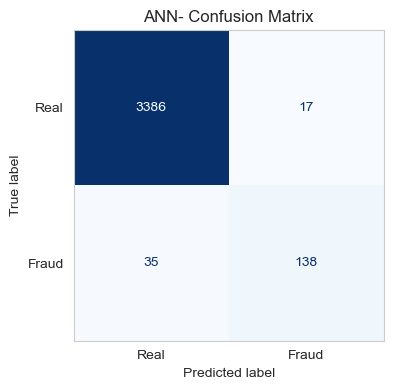

In [5]:
#Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_ann, display_labels=['Real', 'Fraud'],
    cmap='Blues', ax=ax, colorbar=False)
ax.set_title('ANN- Confusion Matrix')
ax.grid(False)
plt.tight_layout()
plt.savefig('../Output/ann_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Findings
 
 - ANN: F1 84, recall 80% - slightly below SVM baseline (F1 87) despite being far more complex
 - Highest AUC-ROC of all models(0.992) - good probability ranking
 - Caught 138 of 173 frauds with 17 false alarms